In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('YearPredictionMSD.txt',header=None)

In [3]:
train=df.iloc[:463715]
test=df.drop(train.index)

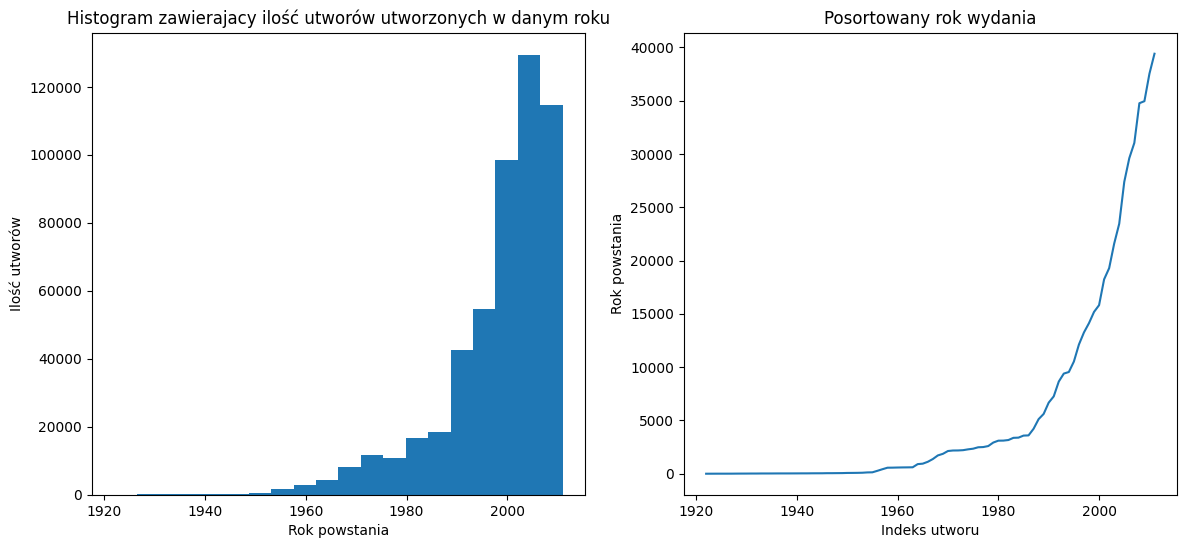

In [4]:

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].hist(df[0],bins=20)
axs[0].set_title("Histogram zawierajacy ilość utworów utworzonych w danym roku")
axs[0].set_xlabel('Rok powstania')
axs[0].set_ylabel('Ilość utworów')

axs[1].plot(np.sort(df[0].unique()),np.sort(df[0].value_counts()))
axs[1].set_title("Posortowany rok wydania")
axs[1].set_xlabel('Indeks utworu')
axs[1].set_ylabel('Rok powstania')

plt.show()

#### (d) Reprezentacje danych dla metody najmniejszych kwadratów

In [5]:
y_train = train[0].values
X_train = train.drop(0, axis=1).values
y_test = test[0].values
X_test = test.drop(0, axis=1).values

# Macierze A (dodajemy kolumnę jedynek)
ones_train = np.ones((X_train.shape[0], 1))
ones_test = np.ones((X_test.shape[0], 1))
A_train = np.hstack((ones_train, X_train))
A_test = np.hstack((ones_test, X_test))

# Normalizacja min-max (fscaled) do przedziału [0, 1] na podstawie zbioru treningowego
X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)

X_train_scaled = (X_train - X_min) / (X_max - X_min)
X_test_scaled = (X_test - X_min) / (X_max - X_min)

A_train_scaled = np.hstack((ones_train, X_train_scaled))
A_test_scaled = np.hstack((ones_test, X_test_scaled))

# Normalizacja dla y
y_min = y_train.min()
y_max = y_train.max()

y_train_scaled = (y_train - y_min) / (y_max - y_min)
y_test_scaled = (y_test - y_min) / (y_max - y_min)


#### (e) Znalezienie wag dla równania normalnego

In [6]:
# Problem najmniejszych kwadratów rozwiązany przy użyciu równania normalnego: (A^T A)w = A^T y
w_unscaled_norm = np.linalg.solve(A_train.T @ A_train, A_train.T @ y_train)

# Dla macierzy znormalizowanych:
w_scaled_norm = np.linalg.solve(A_train_scaled.T @ A_train_scaled, A_train_scaled.T @ y_train_scaled)


#### (f) Rozwiązanie dwiema kolejnymi metodami

In [8]:
import scipy.linalg

# zbiór wag dla reprezentacji nieznormalizowanej (SVD przy użyciu lstsq)
w_unscaled_svd, _, _, _ = scipy.linalg.lstsq(A_train, y_train)


lam = 0.01
# Tworzymy macierz identycznościową
I = np.eye(A_train.shape[1])
I[0, 0] = 0 # nie regularyzujemy współczynnika przy kolumnie jedynek
w_unscaled_reg = np.linalg.solve(A_train.T @ A_train + lam * I, A_train.T @ y_train)


#### (g) Obliczenie współczynników uwarunkowania macierzy

In [9]:
cond_unscaled = np.linalg.cond(A_train.T @ A_train)
cond_scaled = np.linalg.cond(A_train_scaled.T @ A_train_scaled)

print(f"Współczynnik uwarunkowania nieznormalizowanej macierzy (A^T A): {cond_unscaled:.4f}, utrata {np.round(np.log10(cond_unscaled))} miejsc znaczacych")
print(f"Współczynnik uwarunkowania znormalizowanej macierzy: {cond_scaled:.4f}, utrata {np.round(np.log10(cond_scaled))} miejsc znaczacych")

Współczynnik uwarunkowania nieznormalizowanej macierzy (A^T A): 3873665562.9794, utrata 10.0 miejsc znaczacych
Współczynnik uwarunkowania znormalizowanej macierzy: 2146480.9788, utrata 6.0 miejsc znaczacych


#### (h) Predykcje wydania utworu na zbiorze testowym oraz Średni Błąd Bezwzględny (MAE)

In [10]:
# 1. Równanie normalne (nieznormalizowane)
y_pred_unscaled = A_test @ w_unscaled_norm
mae_unscaled = np.mean(np.abs(y_test - y_pred_unscaled))

# 2. Równanie normalne (znormalizowane)
y_pred_scaled = A_test_scaled @ w_scaled_norm
# Cofnięcie normalizacji min-max wedle wzoru (3): y_unscaled = y_hat * (y_max - y_min) + y_min
y_pred_scaled_unscaled = y_pred_scaled * (y_max - y_min) + y_min
mae_scaled = np.mean(np.abs(y_test - y_pred_scaled_unscaled))

# 3. scipy.linalg.lstsq (SVD) nieznormalizowane
y_pred_svd = A_test @ w_unscaled_svd
mae_svd = np.mean(np.abs(y_test - y_pred_svd))

# 4. Równanie zregularyzowane (lambda = 0.01) nieznormalizowane
y_pred_reg = A_test @ w_unscaled_reg
mae_reg = np.mean(np.abs(y_test - y_pred_reg))

print(f"MAE równanie normalne (nieznormalizowane): {mae_unscaled}")
print(f"MAE równanie normalne (znormalizowane): {mae_scaled}")
print(f"MAE lstsq z SVD (nieznormalizowane): {mae_svd}")
print(f"MAE zregularyzowane nieznormalizowane (lambda=0.01): {mae_reg}")


MAE równanie normalne (nieznormalizowane): 6.800496463188447
MAE równanie normalne (znormalizowane): 6.8004964631867715
MAE lstsq z SVD (nieznormalizowane): 6.800496463186179
MAE zregularyzowane nieznormalizowane (lambda=0.01): 6.800496463503586


#### (i) Inkrementacyjne wyliczanie wektora wag za pomocą Filtru Kalmana

In [11]:
P_inv = 1e-5 * np.eye(A_train.shape[1]) # Inicjalizacja bardzo małym szumem
w_kalman = np.zeros(A_train.shape[1])

batches = [
    (0, 100000),         # A1
    (100000, 200000),    # A2
    (200000, 300000),    # A3
    (300000, 400000),    # A4
    (400000, A_train.shape[0])   # A5 (ostatnie 63 715)
]

for idx, (start_i, end_i) in enumerate(batches):
    A_k = A_train[start_i:end_i]
    y_k = y_train[start_i:end_i]
    
    # a priori
    e_k = y_k - A_k @ w_kalman
    
    # Aktualizacja estymatorów
    P_inv += A_k.T @ A_k
    
    # Obliczenie w_{k} wykorzystujące solver dla równania liniowego
    w_kalman += np.linalg.solve(P_inv, A_k.T @ e_k)
    
    # Ewaluacja wektora wag z danej iteracji na zbiorze testowym
    y_pred_k = A_test @ w_kalman
    mae_kalman = np.mean(np.abs(y_test - y_pred_k))
    
    print(f"Iteracja {idx+1} (wiersze {start_i}-{end_i}): MAE kalmana = {mae_kalman}")


Iteracja 1 (wiersze 0-100000): MAE kalmana = 6.846107886906512
Iteracja 2 (wiersze 100000-200000): MAE kalmana = 6.806517829069184
Iteracja 3 (wiersze 200000-300000): MAE kalmana = 6.799756086391904
Iteracja 4 (wiersze 300000-400000): MAE kalmana = 6.8010745706244915
Iteracja 5 (wiersze 400000-463715): MAE kalmana = 6.800496440845691
